Libraries loaded.
  Model   : gpt-4o-mini
  DB path : ./dev/dev_20240627/dev_databases/dev_databases/financial/financial.sqlite
Total questions: 60

[Difficulty distribution]
difficulty
simple         22
moderate       21
challenging    17
Name: count, dtype: int64

[Category distribution]
category
loan_portfolio          11
regional_risk           11
transaction_behavior    11
default_risk            10
client_profile          10
card_risk                7
Name: count, dtype: int64

[Gold SQL Validation]
  CR01 ✓  rows=1
  CR02 ✓  rows=1
  CR03 ✓  rows=1
  CR04 ✓  rows=5
  CR05 ✓  rows=6
  CR06 ✓  rows=2
  CR07 ✓  rows=1
  CR08 ✓  rows=1
  CR09 ✓  rows=1
  CR10 ✓  rows=1
  CR11 ✓  rows=1
  CR12 ✓  rows=2
  CR13 ✓  rows=37
  CR14 ✓  rows=77
  CR15 ✓  rows=1
  CR16 ✓  rows=1
  CR17 ✓  rows=20
  CR18 ✓  rows=1
  CR19 ✓  rows=1
  CR20 ✓  rows=5
  CR21 ✓  rows=77
  CR22 ✓  rows=127
  CR23 ✓  rows=2
  CR24 ✓  rows=1
  CR25 ✓  rows=6
  CR26 ✓  rows=2
  CR27 ✓  rows=1
  CR28 ✓  rows=1
  CR29 

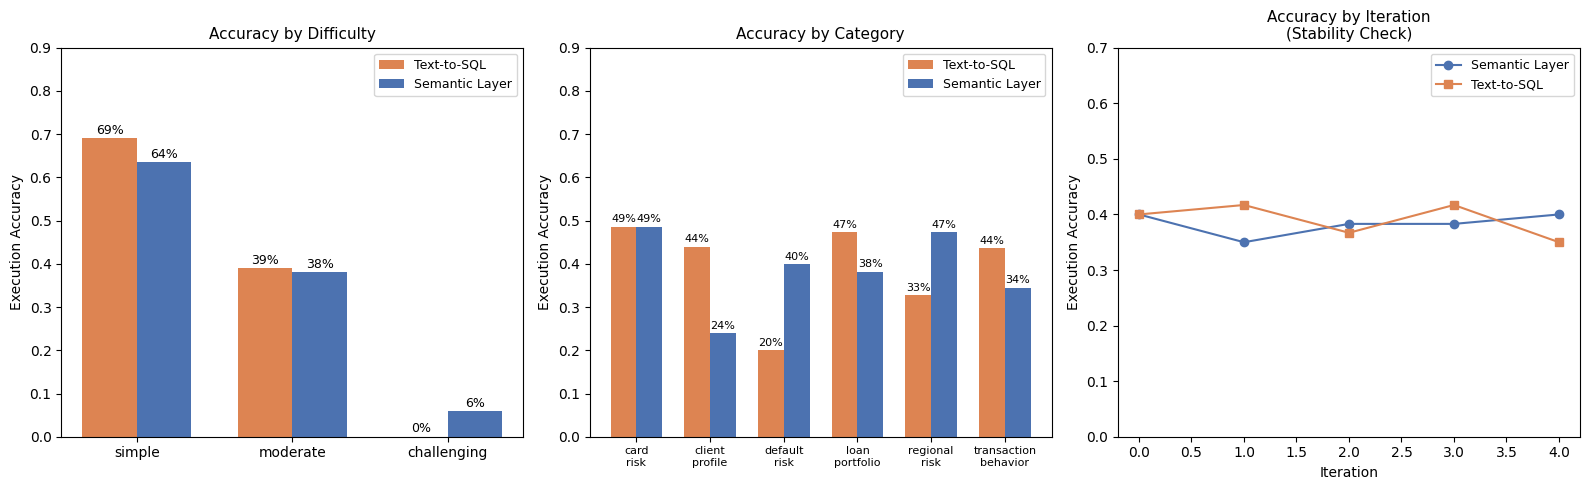

Saved: results_credit_benchmark.png


In [1]:
# ============================================================
# credit_rating_benchmark_experiment.ipynb
# Semantic Layer vs Text-to-SQL
# Credit Rating Domain Benchmark Experiment
#
# Dataset : credit_rating_questions_all.json (60 questions)
# Model   : gpt-4o-mini
# Method  : 2 conditions × 5 iterations = 300 records per method
# Author  : [Your Name]
# Date    : 2026-05-14
# ============================================================


# %% [markdown]
# ## 0. Libraries and Configuration

# %%
import os
import json
import sqlite3
import time
import threading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from utils import (
    DB_PATH, MODEL,
    query_text_to_sql, query_semantic_layer,
    evaluate,
)

load_dotenv()

Q_PATH1  = "./credit_rating_questions.json"
Q_PATH2  = "./credit_rating_questions_add.json"
Q_MERGED = "./credit_rating_questions_all.json"

print("Libraries loaded.")
print(f"  Model   : {MODEL}")
print(f"  DB path : {DB_PATH}")


# %% [markdown]
# ## 1. Load and Validate Question Set (60 questions)

# %%
# Merge question sets
with open(Q_PATH1, "r", encoding="utf-8") as f:
    q1 = json.load(f)
with open(Q_PATH2, "r", encoding="utf-8") as f:
    q2 = json.load(f)

questions_all = q1 + q2

with open(Q_MERGED, "w", encoding="utf-8") as f:
    json.dump(questions_all, f, indent=2, ensure_ascii=False)

df_q = pd.DataFrame(questions_all)

print(f"Total questions: {len(df_q)}")
print(f"\n[Difficulty distribution]")
print(df_q['difficulty'].value_counts())
print(f"\n[Category distribution]")
print(df_q['category'].value_counts())

# Validate all gold SQLs
print(f"\n[Gold SQL Validation]")
conn   = sqlite3.connect(DB_PATH)
errors = []
for _, row in df_q.iterrows():
    try:
        result = pd.read_sql(row['SQL'], conn)
        print(f"  {row['question_id']} ✓  rows={len(result)}")
    except Exception as e:
        errors.append(row['question_id'])
        print(f"  {row['question_id']} ✗  ERROR: {e}")
conn.close()

print(f"\nValid: {len(df_q) - len(errors)} / {len(df_q)}")
if not errors:
    print("All gold SQLs validated. Ready for experiment.")


# %% [markdown]
# ## 2. Execution Speed Check

# %%
SLOW_THRESHOLD = 5.0

print(f"[Gold SQL execution time — threshold: {SLOW_THRESHOLD}s]")
conn     = sqlite3.connect(DB_PATH)
slow_ids = []

for row in questions_all:
    t0 = time.time()
    try:
        df_tmp  = pd.read_sql(row['SQL'], conn)
        elapsed = time.time() - t0
        flag    = " ⚠ SLOW" if elapsed > SLOW_THRESHOLD else ""
        print(f"  {row['question_id']} ({row['difficulty']:<12}) "
              f"✓ {elapsed:.2f}s  rows={len(df_tmp)}{flag}")
        if elapsed > SLOW_THRESHOLD:
            slow_ids.append(row['question_id'])
    except Exception as e:
        print(f"  {row['question_id']} ✗ ERROR: {e}")
        slow_ids.append(row['question_id'])

conn.close()
print(f"\nSlow/Error: {slow_ids if slow_ids else 'None'}")


# %% [markdown]
# ## 3. Timeout Wrappers

# %%
def call_with_timeout(method_fn, question, evidence, timeout=25):
    """Call LLM query function with time limit."""
    result_holder = [None]
    error_holder  = [None]

    def target():
        try:
            result_holder[0] = method_fn(question, evidence)
        except Exception as e:
            error_holder[0] = str(e)

    t = threading.Thread(target=target)
    t.start()
    t.join(timeout)

    if t.is_alive():
        return None, f"Timeout after {timeout}s"
    if error_holder[0]:
        return None, error_holder[0]
    return result_holder[0], None


def evaluate_with_timeout(generated_sql, gold_sql, timeout=10):
    """evaluate() with SQLite execution timeout."""
    result_holder = [None]

    def target():
        try:
            result_holder[0] = evaluate(generated_sql, gold_sql)
        except Exception as e:
            result_holder[0] = {'is_correct': False, 'error': str(e)}

    t = threading.Thread(target=target)
    t.start()
    t.join(timeout)

    if t.is_alive():
        return {'is_correct': False, 'error': f'SQL eval timeout after {timeout}s'}
    return result_holder[0]


print("Timeout wrappers defined.")


# %% [markdown]
# ## 4. Batch Experiment (60 questions × 5 iterations)

# %%
RESULTS_PATH = "./results_phase3_v2.csv"
N_ITER       = 5

with open(Q_MERGED, "r", encoding="utf-8") as f:
    questions = json.load(f)

df_q  = pd.DataFrame(questions)
total = len(df_q)

# Resume from saved results
try:
    df_saved = pd.read_csv(RESULTS_PATH)
    results  = df_saved.to_dict('records')
    done_ids = set(
        q_id for q_id, grp in df_saved.groupby('question_id')
        if grp['iteration'].nunique() >= N_ITER
    )
    print(f"Resuming — completed: {len(done_ids)} / {total}")
except FileNotFoundError:
    results  = []
    done_ids = set()
    print("Starting fresh.")

print(f"Remaining   : {total - len(done_ids)} questions")
print(f"API calls   : {(total - len(done_ids)) * 2 * N_ITER}")
print(f"Model       : {MODEL}")
print("=" * 65)

for i, (_, row) in enumerate(df_q.iterrows()):
    q_id       = row['question_id']
    question   = row['question']
    evidence   = row['evidence']
    gold_sql   = row['SQL']
    difficulty = row['difficulty']
    category   = row['category']

    if q_id in done_ids:
        print(f"[{i+1:2d}/{total}] {q_id} — skipped (done)")
        continue

    iter_correct = {'text_to_sql': 0, 'semantic_layer': 0}

    for iteration in range(N_ITER):
        for method_fn, method_name in [
            (query_text_to_sql,    'text_to_sql'),
            (query_semantic_layer, 'semantic_layer'),
        ]:
            res, timeout_err = call_with_timeout(method_fn, question, evidence)

            if timeout_err:
                results.append({
                    'question_id': q_id, 'difficulty': difficulty,
                    'category'   : category, 'method': method_name,
                    'iteration'  : iteration, 'is_correct': False,
                    'error'      : timeout_err, 'latency_ms': None,
                    'prompt_chars': None, 'generated_sql': None,
                    'gold_sql'   : gold_sql, 'question': question,
                })
                continue

            ev      = evaluate_with_timeout(res['sql'], gold_sql)
            correct = bool(ev['is_correct'])
            if correct:
                iter_correct[method_name] += 1

            results.append({
                'question_id' : q_id, 'difficulty': difficulty,
                'category'    : category, 'method': method_name,
                'iteration'   : iteration, 'is_correct': correct,
                'error'       : ev.get('error'), 'latency_ms': res['latency_ms'],
                'prompt_chars': res['prompt_chars'], 'generated_sql': res['sql'],
                'gold_sql'    : gold_sql, 'question': question,
            })

        time.sleep(0.3)

    pd.DataFrame(results).to_csv(RESULTS_PATH, index=False, encoding='utf-8-sig')

    df_tmp  = pd.DataFrame(results)
    acc     = df_tmp.groupby('method')['is_correct'].mean()
    sql_acc = acc.get('text_to_sql',    float('nan'))
    sl_acc  = acc.get('semantic_layer', float('nan'))
    print(f"[{i+1:2d}/{total}] {q_id} ({difficulty[:3]}/{category[:8]}) "
          f"SQL={iter_correct['text_to_sql']}/{N_ITER} "
          f"SL={iter_correct['semantic_layer']}/{N_ITER} | "
          f"Running: SQL={sql_acc:.1%} SL={sl_acc:.1%}")

print("=" * 65)
print(f"Experiment complete. Saved: {RESULTS_PATH}")
print(pd.DataFrame(results).groupby('method')['is_correct'].mean().round(3))


# %% [markdown]
# ## 5. Results Analysis

# %%
df_res = pd.read_csv(RESULTS_PATH)

print(f"Total records : {len(df_res)}")
print(f"Questions     : {df_res['question_id'].nunique()}")
print(f"Iterations    : {df_res['iteration'].nunique()}")

overall = df_res.groupby('method')['is_correct'].mean().round(3)
by_diff = df_res.groupby(['difficulty','method'])['is_correct'].mean().round(3).unstack()
by_cat  = df_res.groupby(['category','method'])['is_correct'].mean().round(3).unstack()
by_iter = df_res.groupby(['iteration','method'])['is_correct'].mean().round(3).unstack()

print("\n" + "=" * 55)
print("[1] Overall Accuracy (n=60 × 5iter = 300 per method)")
print("=" * 55)
print(overall)
diff = overall['semantic_layer'] - overall['text_to_sql']
print(f"\nDifference: {diff:+.3f} ({'SL' if diff>0 else 'SQL'} advantage)")

print("\n[2] Accuracy by Difficulty")
print(by_diff)

print("\n[3] Accuracy by Category")
print(by_cat)

print("\n[4] Iteration Stability")
print(by_iter)
print(f"\nSL  std: {by_iter['semantic_layer'].std():.4f}")
print(f"SQL std: {by_iter['text_to_sql'].std():.4f}")

print("\n[5] Error Analysis")
for method in ['text_to_sql', 'semantic_layer']:
    sub    = df_res[df_res['method'] == method]
    label  = 'Semantic Layer' if method == 'semantic_layer' else 'Text-to-SQL'
    correct= int(sub['is_correct'].sum())
    errors = int(sub['error'].notna().sum())
    n      = len(sub)
    print(f"  [{label}] correct={correct}/{n} ({correct/n:.1%})  "
          f"exec_errors={errors} ({errors/n:.1%})")

print("\n[6] Latency (ms)")
print(df_res.groupby('method')['latency_ms'].agg(['mean','median','std']).round(1))


# %% [markdown]
# ## 6. Visualization

# %%
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
w = 0.35

# Figure 1: Accuracy by difficulty
ax1   = axes[0]
diffs = ['simple', 'moderate', 'challenging']
x     = np.arange(len(diffs))
for j, (method, color, label) in enumerate([
    ('text_to_sql',    '#DD8452', 'Text-to-SQL'),
    ('semantic_layer', '#4C72B0', 'Semantic Layer'),
]):
    vals = [by_diff.loc[d, method] if d in by_diff.index else 0 for d in diffs]
    bars = ax1.bar(x + (j-0.5)*w, vals, w, label=label, color=color)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f'{val:.0%}', ha='center', fontsize=9)
ax1.set_title('Accuracy by Difficulty', fontsize=11)
ax1.set_xticks(x); ax1.set_xticklabels(diffs)
ax1.set_ylabel('Execution Accuracy')
ax1.set_ylim(0, 0.9); ax1.legend(fontsize=9)

# Figure 2: Accuracy by category
ax2  = axes[1]
cats = by_cat.index.tolist()
x2   = np.arange(len(cats))
for j, (method, color, label) in enumerate([
    ('text_to_sql',    '#DD8452', 'Text-to-SQL'),
    ('semantic_layer', '#4C72B0', 'Semantic Layer'),
]):
    vals = [by_cat.loc[c, method] for c in cats]
    bars = ax2.bar(x2 + (j-0.5)*w, vals, w, label=label, color=color)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f'{val:.0%}', ha='center', fontsize=8)
ax2.set_title('Accuracy by Category', fontsize=11)
ax2.set_xticks(x2)
ax2.set_xticklabels([c.replace('_', '\n') for c in cats], fontsize=8)
ax2.set_ylabel('Execution Accuracy')
ax2.set_ylim(0, 0.9); ax2.legend(fontsize=9)

# Figure 3: Iteration stability
ax3 = axes[2]
ax3.plot(by_iter.index, by_iter['semantic_layer'],
         marker='o', label='Semantic Layer', color='#4C72B0')
ax3.plot(by_iter.index, by_iter['text_to_sql'],
         marker='s', label='Text-to-SQL',    color='#DD8452')
ax3.set_title('Accuracy by Iteration\n(Stability Check)', fontsize=11)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Execution Accuracy')
ax3.set_ylim(0, 0.7); ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results_credit_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_credit_benchmark.png")